In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# Generar datos
X, y = make_regression(ss
    n_samples=200,
    n_features=3,
    noise=15,
    random_state=42
)

# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)

Forma de X_train: (150, 3)
Forma de X_test: (50, 3)


In [3]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Crear el modelo
modelo = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

# Calcular RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calcular R²
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)


RMSE: 31.060077682474056
R²: 0.9016306566641975


In [12]:
import numpy as np

real = np.array([700, 850, 600, 900])
predicho = np.array([720, 800, 650, 880])

error = predicho - real
print("Errores:", error)

error_cuadrado = error ** 2
print("Errores al cuadrado:", error_cuadrado)

mse = np.mean(error_cuadrado)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

print(f"El error medio del modelo es de {rmse:.2f} €")


Errores: [ 20 -50  50 -20]
Errores al cuadrado: [ 400 2500 2500  400]
MSE: 1450.0
RMSE: 38.07886552931954
El error medio del modelo es de 38.08 €


In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# 1. Cargar datos
iris = load_iris()
X, y = iris.data, iris.target

# 2. Separar train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Crear y entrenar el modelo
modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

# 4. Generar predicciones
y_pred = modelo.predict(X_test)

# 5. Calcular accuracy
accuracy = modelo.score(X_test, y_test)

print("Predicciones:", y_pred)
print("Accuracy:", accuracy)

Predicciones: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]
Accuracy: 0.9


In [13]:
TP = 35
TN = 50
FP = 5
FN = 10

total = TP + TN + FP + FN

# 1. Accuracy
accuracy = (TP + TN) / total
print("Accuracy:", accuracy * 100, "%")

# 2. Precisión
precision = TP / (TP + FP)
print("Precisión:", precision * 100, "%")

# 3. Recall
recall = TP / (TP + FN)
print("Recall:", recall * 100, "%")

# 4. Métrica más importante
print("Métrica más importante: Recall")

Accuracy: 85.0 %
Precisión: 87.5 %
Recall: 77.77777777777779 %
Métrica más importante: Recall


In [1]:
import os
os.environ["OMP_NUM_THREADS"]="1"
os.environ["MKL_NUM_THREADS"]="1"
os.environ["OPENBLAS_NUM_THREADS"]="1"
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generar datos con 3 grupos
X, y_real = make_blobs(
    n_samples=150,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

# Crear el modelo
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Ajustar el modelo y obtener etiquetas
etiquetas = kmeans.fit_predict(X)

# Mostrar los centroides
print("Centroides encontrados:")
print(kmeans.cluster_centers_)

print("Etiquetas de los puntos:")
print(etiquetas)


Centroides encontrados:
[[-2.70146566  8.90287872]
 [-6.75399588 -6.88944874]
 [ 4.58407676  2.1431444 ]]
Etiquetas de los puntos:
[0 0 1 2 1 2 0 0 1 2 1 1 2 1 2 0 1 0 2 2 0 1 2 1 2 1 1 0 1 2 2 0 1 1 2 2 1
 1 2 0 0 1 0 0 2 0 0 2 0 1 0 2 2 0 0 1 0 2 1 0 1 1 1 2 2 2 2 1 2 2 1 0 2 0
 0 0 2 2 2 0 0 1 0 1 2 0 0 2 1 0 1 0 0 1 1 2 1 1 0 2 2 2 0 0 2 0 1 2 0 1 1
 0 2 1 1 2 1 2 1 0 1 1 2 1 0 1 1 2 2 1 0 0 2 2 0 2 1 2 2 1 0 0 1 2 0 0 1 0
 0 2]


[9862.490245314735, 2752.929084732387, 283.60067487251115, 242.8476788151304, 211.23737091128962, 177.91101015015644]


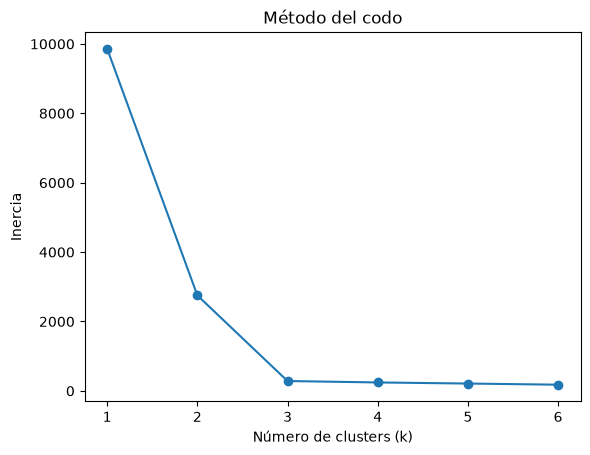

In [2]:
from sklearn.cluster import KMeans

inercias = []

for k in range(1, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    inercias.append(kmeans.inertia_)

print(inercias)

import matplotlib.pyplot as plt

k_values = range(1, 7)

plt.plot(k_values, inercias, marker='o')

plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')

plt.show()



In [8]:
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Crear el clasificador
clf = RandomForestClassifier(
    random_state=42
)
# Validación cruzada con 5 particiones
puntuaciones = cross_val_score(
    clf,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro"
)

print("Puntuaciones:", puntuaciones)

for i, puntuacion in enumerate(puntuaciones, start=1):
    print(f"Partición {i}: {puntuacion:.4f}")

    media = np.mean(puntuaciones)
desviacion = np.std(puntuaciones)

print(f"Media: {media:.4f}")
print(f"Desviación estándar: {desviacion:.4f}")


Puntuaciones: [0.91534392 0.95816993 0.95816993 0.95816993 0.95816993]
Partición 1: 0.9153
Partición 2: 0.9582
Partición 3: 0.9582
Partición 4: 0.9582
Partición 5: 0.9582
Media: 0.9496
Desviación estándar: 0.0171


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# Definir los hiperparámetros
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 3, 5]
}
grid_search = GridSearchCV(modelo, param_grid, cv=5, scoring="f1_macro")

grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print("Mejor puntuación F1-macro:")
print(grid_search.best_score_)



Mejores hiperparámetros:
{'max_depth': 3, 'n_estimators': 50}
Mejor puntuación F1-macro:
0.9581699346405228
